The code below will:

Read each CSV in the directory;
Skip files whose number of columns is not 9, whose region count is incorrect, or whose clause count is not 46;
Compute a region × region policy diff-rate matrix for each app;
Then compute the mean across the matrices of all apps;
Output to a single Excel file containing:

In [33]:
import pandas as pd
import numpy as np
from itertools import combinations
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.utils import get_column_letter
from pathlib import Path

In [34]:
input_folder = Path("dataset\AA1_first_batch\pp_matrix_output")
# output_file = "dataset\\AA1_first_batch\AA2_second_100_batch\\analysis_pp_output\\privacy_policy_difference_rate_results.xlsx"
output_file = "dataset\\AA1_first_batch\\analysis_pp_output\\privacy_policy_difference_rate_results.xlsx"

def compute_diff_rate_matrix_from_policy(policy_df, clause_col="Clause"):
    mat = policy_df.set_index(clause_col)

    regions = list(mat.columns)
    num_clauses = mat.shape[0]

    mat = mat.astype(int)

    diff_rate_matrix = pd.DataFrame(
        np.zeros((len(regions), len(regions))),
        index=regions,
        columns=regions
    )

    for r1, r2 in combinations(regions, 2):
        diff_count = (mat[r1] != mat[r2]).sum()
        # diff_rate = diff_count
        diff_rate = diff_count / num_clauses


        diff_rate_matrix.loc[r1, r2] = diff_rate
        diff_rate_matrix.loc[r2, r1] = diff_rate

    return diff_rate_matrix


app_matrices = {}

for file_path in input_folder.glob("*.csv"):
    app_name = file_path.stem
    print(f"Processing {file_path}...")
    policy_df = pd.read_csv(file_path)

    if policy_df.shape[1] != 12:
        print(f"Warning: {app_name} has {policy_df.shape[1]} regions, expected 12.")
        continue
    # print(policy_df.head())

    diff_rate_matrix = compute_diff_rate_matrix_from_policy(policy_df)

    if (diff_rate_matrix == 0).all().all():
        print(f"all is 0 for {app_name}, skipping.")
        continue

    print(f"Diff rate matrix for {app_name}:\n{diff_rate_matrix}")

    app_matrices[app_name] = diff_rate_matrix

print("Number of apps:", len(app_matrices))

# average matrix
first_matrix = next(iter(app_matrices.values()))
avg_matrix = pd.DataFrame(
    np.zeros(first_matrix.shape),
    index=first_matrix.index,
    columns=first_matrix.columns
)

for app_name, matrix in app_matrices.items():
    avg_matrix += matrix

avg_matrix = avg_matrix / len(app_matrices)
avg_matrix.to_csv("dataset\\AA1_first_batch\\analysis_pp_output\\pp_average_diff_rate.csv", index=True)

# save
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    avg_matrix.to_excel(writer, sheet_name="average_diff_rate")

    for app_name, matrix in app_matrices.items():
        sheet_name = str(app_name)[:31]
        matrix.to_excel(writer, sheet_name=sheet_name)

print(f"Saved to {output_file}")

Processing dataset\AA1_first_batch\pp_matrix_output\air.com.spilgames.TrollFaceQuestVideoGames2.csv...
all is 0 for air.com.spilgames.TrollFaceQuestVideoGames2, skipping.
Processing dataset\AA1_first_batch\pp_matrix_output\alarm.clock.night.watch.talking.csv...
all is 0 for alarm.clock.night.watch.talking, skipping.
Processing dataset\AA1_first_batch\pp_matrix_output\any.splitscreen.csv...
all is 0 for any.splitscreen, skipping.
Processing dataset\AA1_first_batch\pp_matrix_output\app.phantom.csv...
all is 0 for app.phantom, skipping.
Processing dataset\AA1_first_batch\pp_matrix_output\at.mobilkom.android.meina1.csv...
all is 0 for at.mobilkom.android.meina1, skipping.
Processing dataset\AA1_first_batch\pp_matrix_output\authenticator.two.factor.authentication.otp.csv...
all is 0 for authenticator.two.factor.authentication.otp, skipping.
Processing dataset\AA1_first_batch\pp_matrix_output\azt.azt.csv...
all is 0 for azt.azt, skipping.
Processing dataset\AA1_first_batch\pp_matrix_output\b

Each app × clause × region pair is one observation, and disclosed pairs and diff pairs are then aggregated by clause category.
For each clause category:
total pairs
disclosed pairs: at least one of the regions is 1
diff pairs: the two regions are different
disclosure rate
diff rate over total
diff rate among disclosed
Excel
Bar-chart PNG

Input: read app sheet names from the previously generated Excel file and include only the CSV files corresponding to those apps.

In [27]:
# app_matrices

In [25]:
from pathlib import Path
from itertools import combinations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
input_folder = Path(r"dataset\AA1_first_batch\pp_matrix_output")
app_matrix_file = Path(
    r"dataset\AA1_first_batch\analysis_pp_output\privacy_policy_difference_results.xlsx"
)

output_file = Path(
    r"dataset\AA1_first_batch\analysis_pp_output\privacy_policy_category_difference_bar_chart.xlsx"
)
output_fig = output_file.with_suffix(".pdf")
output_file.parent.mkdir(parents=True, exist_ok=True)


# Read the sheet names from the previously generated app_matrices output as the valid app list
xls = pd.ExcelFile(app_matrix_file)

exclude_sheets = {
    "average_diff_rate"
}

valid_app_names = {
    sheet for sheet in xls.sheet_names
    if sheet not in exclude_sheets
}

print(f"Apps selected from app_matrices sheets: {len(valid_app_names)}")

Apps selected from app_matrices sheets: 15


In [27]:
def get_clause_category(clause):
    clause = str(clause).strip()

    if clause.startswith("CR"):
        return "CR" #Controller & Recipient"
    elif clause.startswith("P"):
        return "P" #"Personal Data Practices"
    elif clause.startswith("C"):
        return  "C" #"Consent"
    elif clause.startswith("R") or clause.startswith("E"):
        return "R" #Rights
    else:
        return "O" #Others


summary = {}
detail_rows = []
used_apps = []
skipped_apps = []

In [28]:
for file_path in sorted(input_folder.glob("*.csv")):
    app_name = file_path.stem

    # Include only apps that appear in app_matrices
    if app_name not in valid_app_names:
        continue

    # print(f"Processing {app_name}...")

    try:
        
        policy_df = pd.read_csv(file_path)

        if policy_df.shape[1] != 12:
            skipped_apps.append({
                "app": app_name,
                "reason": f"Expected 12 columns: Clause + 11 regions, got {policy_df.shape[1]}"
            })
            continue
        
        if "Clause" not in policy_df.columns:
            skipped_apps.append({
                "app": app_name,
                "reason": "Missing Clause column"
            })
            continue
        
        # if policy_df.shape[0] != 46:
        #     skipped_apps.append({
        #         "app": app_name,
        #         "reason": f"Expected 46 clauses, got {policy_df.shape[0]}"
        #     })
        #     continue

        print(f"Processing {app_name}...")

        region_cols = [c for c in policy_df.columns if c != "Clause"]
        policy_df[region_cols] = policy_df[region_cols].astype(int)
        policy_df["Category"] = policy_df["Clause"].apply(get_clause_category)

        used_apps.append(app_name)

        for _, row in policy_df.iterrows():
            category = row["Category"]

            if category not in summary:
                summary[category] = {
                    "total_pairs": 0,
                    "disclosed_pairs": 0,
                    "diff_pairs": 0
                }

            for r1, r2 in combinations(region_cols, 2):
                v1 = int(row[r1])
                v2 = int(row[r2])

                disclosed = int((v1 == 1) or (v2 == 1))
                diff = int(v1 != v2)

                summary[category]["total_pairs"] += 1
                summary[category]["disclosed_pairs"] += disclosed
                summary[category]["diff_pairs"] += diff

                detail_rows.append({
                    "app": app_name,
                    "clause": row["Clause"],
                    "category": category,
                    "region_1": r1,
                    "region_2": r2,
                    "value_1": v1,
                    "value_2": v2,
                    "disclosed": disclosed,
                    "diff": diff
                })

    except Exception as e:
        skipped_apps.append({
            "app": app_name,
            "reason": str(e)
        })


summary_df = pd.DataFrame.from_dict(summary, orient="index").reset_index()
summary_df = summary_df.rename(columns={"index": "category"})
print(summary_df["disclosed_pairs"], summary_df["total_pairs"])
summary_df["disclosure_rate"] = (
    summary_df["disclosed_pairs"] / summary_df["total_pairs"]
)

summary_df["diff_rate_over_total"] = (
    summary_df["diff_pairs"] / summary_df["total_pairs"]
)

summary_df["diff_rate_among_disclosed"] = (
    summary_df["diff_pairs"] / summary_df["disclosed_pairs"].replace(0, np.nan)
)

summary_df = summary_df.sort_values("diff_rate_over_total", ascending=False)

detail_df = pd.DataFrame(detail_rows)
used_apps_df = pd.DataFrame({"app": used_apps})
skipped_apps_df = pd.DataFrame(skipped_apps)

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="category_summary", index=False)
    detail_df.to_excel(writer, sheet_name="pair_level_details", index=False)
    used_apps_df.to_excel(writer, sheet_name="used_apps", index=False)
    skipped_apps_df.to_excel(writer, sheet_name="skipped_apps", index=False)

print(f"Used apps: {len(used_apps)}")
print(f"Skipped apps: {len(skipped_apps)}")
print(f"Saved Excel to: {output_file}")

Processing com.aksis.whocalls...
Processing com.brainium.solitairefree...
Processing com.brave.merge...
Processing com.CalendarMonthlyStyle...
Processing com.CharityRun.game...
Processing com.DefaultCompany.BloodBox...
Processing com.Gongulus.SpreadLegs...
Processing com.happysky.spider...
Processing com.hee.drawcarroad...
Processing com.hepagames.wheelevolution...
Processing com.hg.cartcrash...
Processing com.hgj.wordgames.tr...
Processing com.highcore.hoopstars...
0    3198
1    1014
2      55
3     274
Name: disclosed_pairs, dtype: int64 0    14300
1     3575
2    16445
3     2145
Name: total_pairs, dtype: int64
Used apps: 13
Skipped apps: 0
Saved Excel to: dataset\AA1_first_batch\analysis_pp_output\privacy_policy_category_difference_bar_chart.xlsx


In [ ]:
# # Plot the bar chart
# plot_df = summary_df.copy()

# x = np.arange(len(plot_df))
# width = 0.35

# plt.figure(figsize=(12, 6))
# plt.bar(x - width / 2, plot_df["total_pairs"], width, label="Total pairs")
# plt.bar(x - width / 2, plot_df["disclosed_pairs"], width, label="Disclosed pairs")
# plt.bar(x + width / 2, plot_df["diff_pairs"], width, label="Different pairs")

# plt.xticks(x, plot_df["category"], rotation=30, ha="right", fontsize=16)
# plt.ylabel("Observation Count", fontsize=16) # Number of app-clause-region-pair observations
# plt.title("Privacy Policy Disclosure and Difference by Clause Category", fontsize=16)
# plt.legend()
# plt.tight_layout()
# plt.savefig(output_fig)
# plt.show()

# print(f"Saved figure to: {output_fig}")

#  PD 20, CR 5, C 2, R 16, O 3    36*20*12=8,640, 36*5*12=2,160, 36*2*12=864, 36*16*12=6,912, 36*3*12=1,296    452/8,640=0.0523,  110/2,160=0.0304,  48/6,912=0.0069,  0/1,296=0

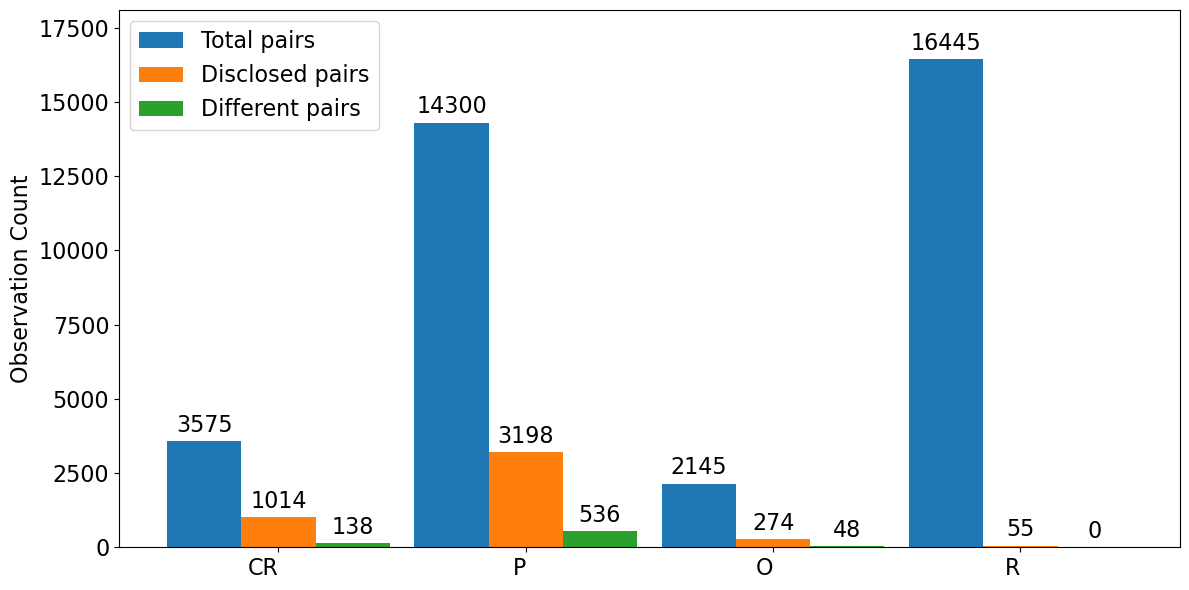

Saved figure to: dataset\AA1_first_batch\analysis_pp_output\privacy_policy_category_difference_bar_chart.pdf


In [29]:
# Plot the bar chart
plot_df = summary_df.copy()

x = np.arange(len(plot_df))
width = 0.30

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width,
    plot_df["total_pairs"],
    width,
    label="Total pairs"
)

bars2 = plt.bar(
    x ,
    plot_df["disclosed_pairs"],
    width,
    label="Disclosed pairs"
)

bars3 = plt.bar(
    x + width ,
    plot_df["diff_pairs"],
    width,
    label="Different pairs"
)

plt.bar_label(bars1, padding=3, fontsize=16)
plt.bar_label(bars2, padding=3, fontsize=16)
plt.bar_label(bars3, padding=3, fontsize=16)

ymax = plot_df[["total_pairs", "disclosed_pairs", "diff_pairs"]].to_numpy().max()
plt.ylim(0, ymax * 1.10)

plt.xticks(x, plot_df["category"], ha="right", fontsize=16)
plt.ylabel("Observation Count", fontsize=16) # Number of app-clause-region-pair observations
plt.yticks(fontsize=16)   # Enlarge the y-axis tick labels
# plt.title("Privacy Policy Disclosure and Difference by Clause Category", fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig(output_fig)
plt.show()

print(f"Saved figure to: {output_fig}")

In [ ]:
# cr 138/3575=0.0386013
# p 536/14300=0.03748
# 0 48/2154=0.02228
# r 0

In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

output_file = Path(
    r"dataset\\AA1_first_batch\\analysis_pp_output\privacy_policy_category_difference_bar_chart.xlsx"
)
output_fig = output_file.with_suffix(".pdf")
output_file.parent.mkdir(parents=True, exist_ok=True)

summary_df = pd.read_excel("dataset\\AA1_first_batch\\analysis_pp_output\\P_category_ave.xlsx")
summary_df.head()

,category,total_pairs,disclosed_pairs,diff_pairs,disclosure_rate,diff_rate_over_total,diff_rate_among_disclosed
0,Controller & Recipient,3575,1014,138,0.283636,0.038601,0.136095
1,Personal Data Practices,14300,3198,536,0.223636,0.037483,0.167605
2,Others,2145,274,48,0.127739,0.022378,0.175182
3,Rights,16445,55,0,0.003344,0.000000,0.000000


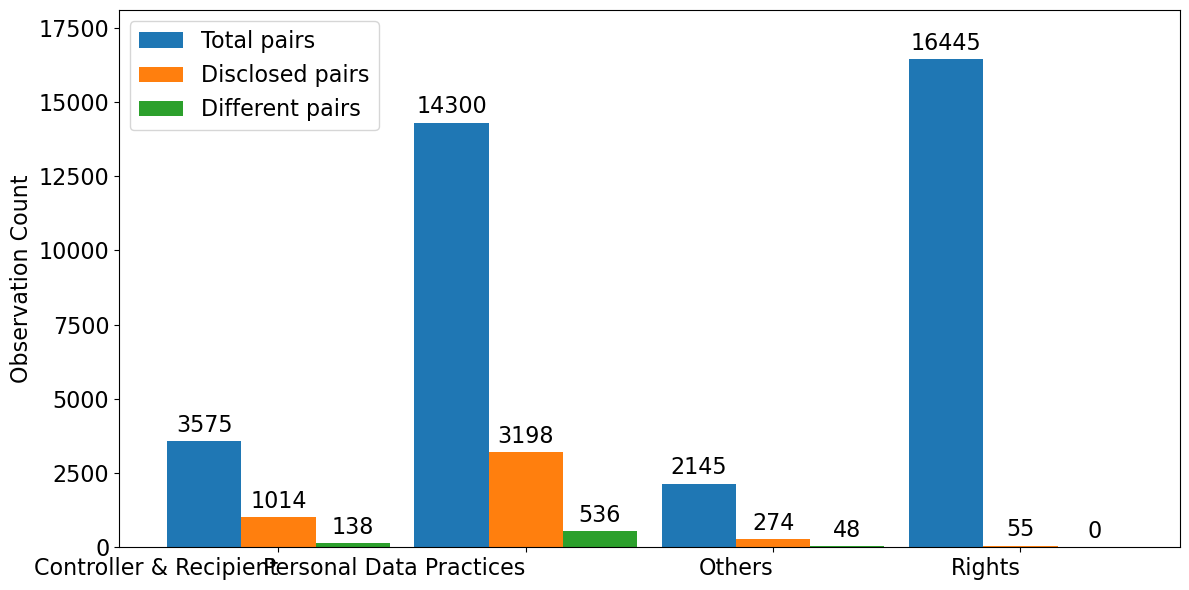

Saved figure to: dataset\AA1_first_batch\analysis_pp_output\privacy_policy_category_difference_bar_chart.pdf


In [18]:
# Plot the bar chart
plot_df = summary_df.copy()

x = np.arange(len(plot_df))
width = 0.30

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width,
    plot_df["total_pairs"],
    width,
    label="Total pairs"
)

bars2 = plt.bar(
    x ,
    plot_df["disclosed_pairs"],
    width,
    label="Disclosed pairs"
)

bars3 = plt.bar(
    x + width ,
    plot_df["diff_pairs"],
    width,
    label="Different pairs"
)

plt.bar_label(bars1, padding=3, fontsize=16)
plt.bar_label(bars2, padding=3, fontsize=16)
plt.bar_label(bars3, padding=3, fontsize=16)

ymax = plot_df[["total_pairs", "disclosed_pairs", "diff_pairs"]].to_numpy().max()
plt.ylim(0, ymax * 1.10)

plt.xticks(x, plot_df["category"], ha="right", fontsize=16)
plt.ylabel("Observation Count", fontsize=16) # Number of app-clause-region-pair observations
plt.yticks(fontsize=16)   # Enlarge the y-axis tick labels
# plt.title("Privacy Policy Disclosure and Difference by Clause Category", fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig(output_fig)
plt.show()

print(f"Saved figure to: {output_fig}")

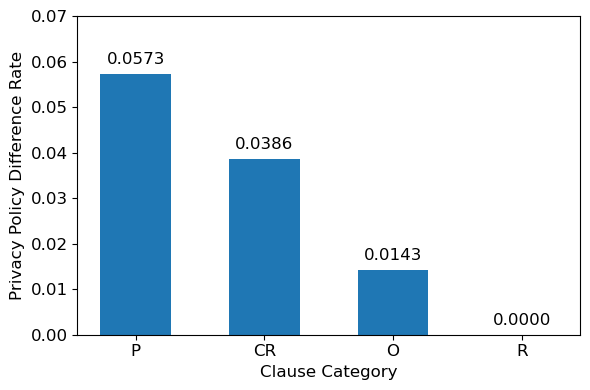

In [32]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

output_file = Path(
    r"dataset\AA1_first_batch\analysis_pp_output\privacy_policy_category_difference_bar_chart.xlsx"
)
# output_fig = output_file.with_suffix(".pdf")
output_file = Path(
    r"dataset\AA1_first_batch\analysis_pp_output\privacy_policy_category_difference_bar_chart2.xlsx"
)
output_file.parent.mkdir(parents=True, exist_ok=True)

categories = ["P", "CR", "O", "R"]
diff_rates = [0.0573, 0.0386013, 0.0143, 0] #  PD 20, CR 5, C 2, R 16, O 3    36*20*31=22,320, 36*5*31=5,580, 36*2*31=2,232, 36*16*31=17,856, 36*3*31=3,348    914/22320=0.0409,  170/5580=0.0304,  0/2232=0,  0/17856=0,  0/3348=0

# 36*20*13= 9,360, 36*5*13= 2,340, 36*2*13= 2,232, 36*16*13= 17,856, 36*3*13= 3,348    914/22320=0.0409,  170/5580=0.0304,  0/2232=0,  0/17856=0,  0/3348=0
# cr 138/3575=0.0386013   36*5*13=2,340        138/3575=0.0386013
# p 536/14300=0.03748    36*20*13=9,360,       536/9360=0.0573
# 0 48/2154=0.02228       36*3*13=3,348        48/3348=0.0143
# r 0                     36*16*13=17,856      0/17856=0


fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(categories, diff_rates, width=0.55)

ax.set_xlabel("Clause Category", fontsize=12)
ax.set_ylabel("Privacy Policy Difference Rate", fontsize=12)

# Axis tick font size
ax.tick_params(axis="both", labelsize=12)

# Y-axis range and ticks
ax.set_ylim(0, 0.07)
ax.set_yticks(np.arange(0, 0.071, 0.01))

# Display values on the bars
for bar, value in zip(bars, diff_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0015,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.tight_layout()

plt.savefig(
    output_file.with_suffix(".pdf"),
    bbox_inches="tight"
)

plt.show()